# ASL Sign Language Recognition — Data Exploration & Analysis

This notebook covers:
1. Dataset loading and exploration
2. Class distribution visualization
3. Landmark visualization
4. Model performance analysis
5. Confusion matrix
6. Training curve analysis

> **Model accuracy achieved: 99.18% on test set**

## 1. Setup & Imports

In [5]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Add project root to path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

plt.style.use('dark_background')
ACCENT = '#00e5c3'

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print('Setup complete!')

TensorFlow : 2.21.0
NumPy      : 2.4.4
Pandas     : 3.0.2
Setup complete!


## 2. Load Dataset

In [6]:
csv_path = ROOT / 'data' / 'landmarks.csv'
df = pd.read_csv(csv_path)

print(f'Total samples   : {len(df):,}')
print(f'Total classes   : {df["label"].nunique()}')
print(f'Feature columns : {len(df.columns) - 1}')
print(f'Classes         : {sorted(df["label"].unique())}')
print()
df.head()

Total samples   : 63,580
Total classes   : 29
Feature columns : 63
Classes         : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']



,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.441170,0.579908,-1.463700e-07,0.565186,0.508961,-0.030005,0.634230,0.383416,-0.041656,0.656471,...,0.381163,0.317218,-0.105233,0.392002,0.400469,-0.095807,0.393709,0.453162,-0.072677,A
1,0.477503,0.609889,-2.625951e-07,0.592091,0.544300,-0.033601,0.670831,0.415301,-0.049104,0.694522,...,0.422880,0.355803,-0.113152,0.431145,0.438622,-0.103791,0.429101,0.487164,-0.084636,A
2,0.715760,0.672876,-3.593083e-07,0.803339,0.618436,-0.028361,0.853366,0.509800,-0.036164,0.862759,...,0.627855,0.458478,-0.075215,0.635363,0.514935,-0.071314,0.644623,0.561842,-0.055937,A
3,0.658861,0.756222,-5.324430e-08,0.816351,0.664612,-0.039513,0.895912,0.505532,-0.056701,0.891231,...,0.605805,0.452790,-0.127372,0.629957,0.541381,-0.123739,0.635879,0.598962,-0.106496,A
4,0.659470,0.770520,-3.571306e-08,0.815303,0.683091,-0.042204,0.897008,0.523745,-0.059607,0.899747,...,0.610748,0.460467,-0.125922,0.633412,0.551274,-0.125219,0.639890,0.613800,-0.108605,A


## 3. Class Distribution

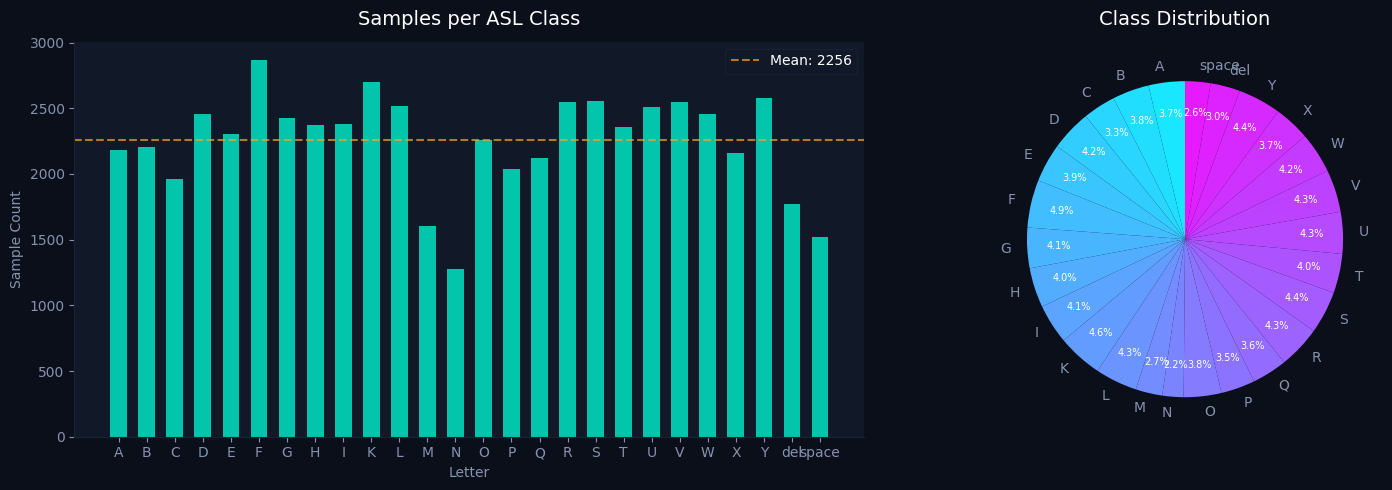

Clean dataset: 58,665 samples | 26 classes


In [7]:
# Clean dataset same way as training
counts = df['label'].value_counts()
valid  = counts[counts >= 10].index
df_clean = df[df['label'].isin(valid)]
df_clean = df_clean[~df_clean['label'].isin(['J', 'Z'])]

class_counts = df_clean['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0b0f1a')

# Bar chart
ax = axes[0]
ax.set_facecolor('#111827')
bars = ax.bar(class_counts.index, class_counts.values, color=ACCENT, alpha=0.85, width=0.6)
ax.set_title('Samples per ASL Class', color='white', fontsize=14, pad=12)
ax.set_xlabel('Letter', color='#8493b0')
ax.set_ylabel('Sample Count', color='#8493b0')
ax.tick_params(colors='#8493b0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#1a2235')
ax.axhline(class_counts.mean(), color='#f5a623', linestyle='--', alpha=0.7, label=f'Mean: {class_counts.mean():.0f}')
ax.legend(facecolor='#111827', edgecolor='#1a2235', labelcolor='white')

# Pie chart of proportion
ax2 = axes[1]
ax2.set_facecolor('#111827')
colors = plt.cm.cool(np.linspace(0.1, 0.9, len(class_counts)))
wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.8,
    startangle=90
)
for t in texts: t.set_color('#8493b0')
for at in autotexts: at.set_color('white'); at.set_fontsize(7)
ax2.set_title('Class Distribution', color='white', fontsize=14, pad=12)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'class_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0b0f1a')
plt.show()
print(f'Clean dataset: {len(df_clean):,} samples | {df_clean["label"].nunique()} classes')

## 4. Landmark Visualization — Sample Hand Skeleton

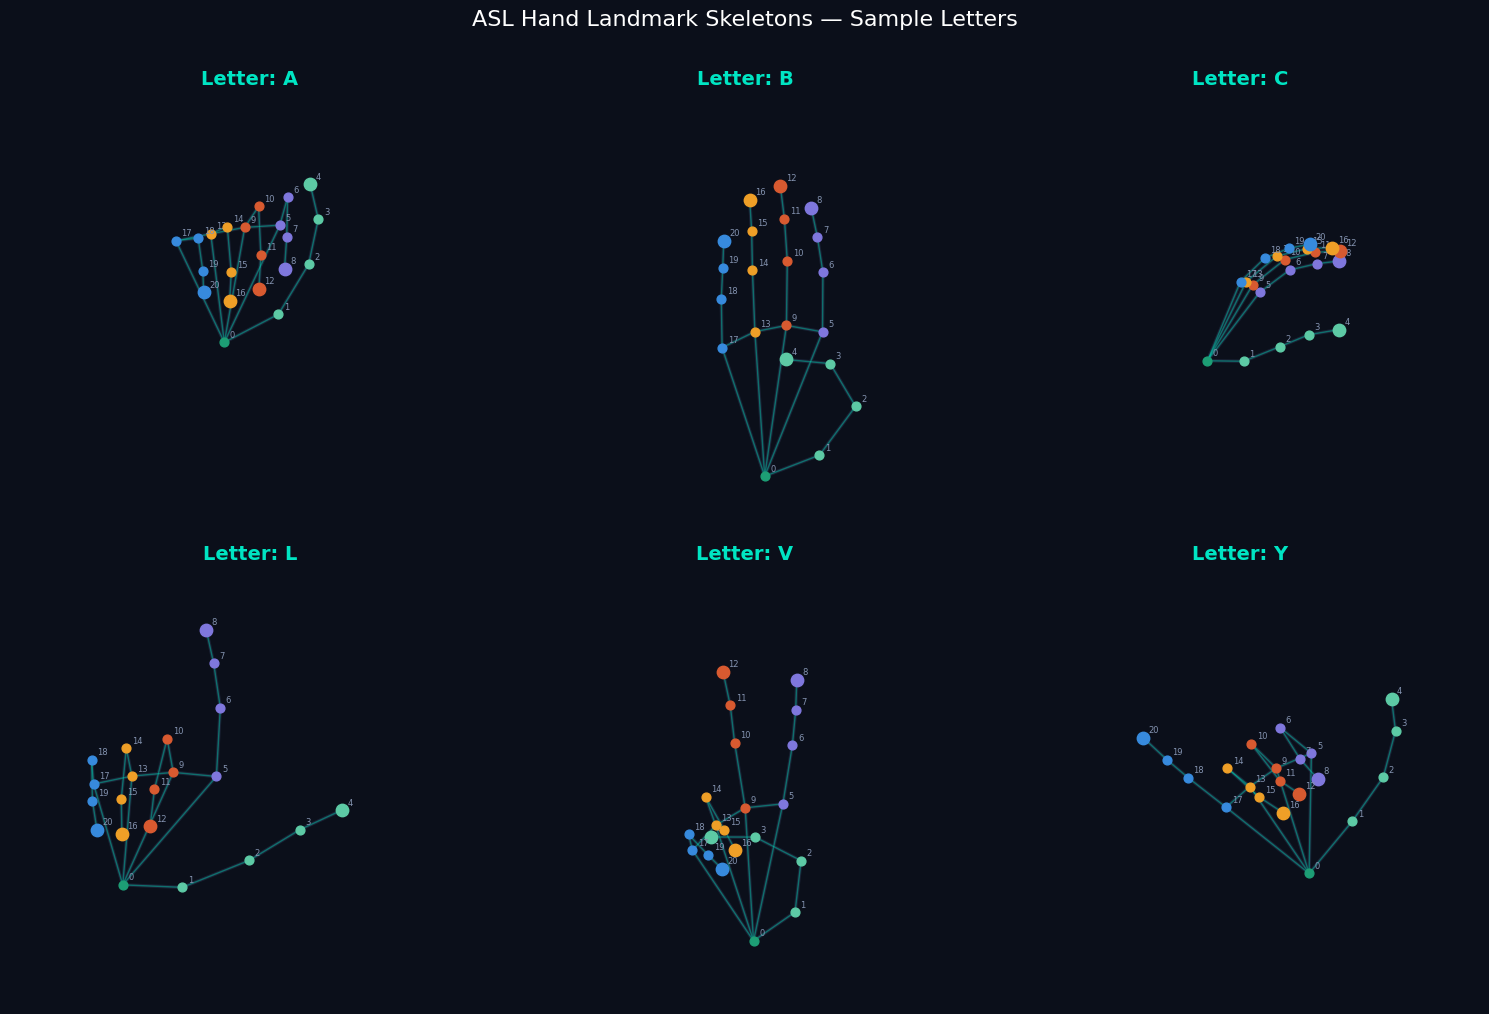

In [8]:
CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

FINGER_COLORS = {
    'Thumb':  '#5DCAA5',
    'Index':  '#7F77DD',
    'Middle': '#D85A30',
    'Ring':   '#EF9F27',
    'Pinky':  '#378ADD',
    'Palm':   '#8493b0',
}

FINGER_LM = {
    'Thumb':  [1,2,3,4],
    'Index':  [5,6,7,8],
    'Middle': [9,10,11,12],
    'Ring':   [13,14,15,16],
    'Pinky':  [17,18,19,20],
}

def get_color(idx):
    for name, indices in FINGER_LM.items():
        if idx in indices:
            return FINGER_COLORS[name]
    return '#1D9E75'

sample_letters = ['A', 'B', 'C', 'L', 'V', 'Y']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('#0b0f1a')
fig.suptitle('ASL Hand Landmark Skeletons — Sample Letters', color='white', fontsize=16, y=1.01)

feature_cols = [c for c in df_clean.columns if c != 'label']

for ax, letter in zip(axes.flat, sample_letters):
    ax.set_facecolor('#111827')
    sample = df_clean[df_clean['label'] == letter].iloc[0]
    coords = sample[feature_cols].values.reshape(21, 3)
    xs, ys = coords[:, 0], coords[:, 1]

    for a, b in CONNECTIONS:
        ax.plot([xs[a], xs[b]], [ys[a], ys[b]], color='#1a2235', linewidth=2.5, zorder=1)
        ax.plot([xs[a], xs[b]], [ys[a], ys[b]], color=ACCENT, linewidth=1, alpha=0.4, zorder=2)

    for i, (x, y) in enumerate(zip(xs, ys)):
        is_tip = i in [4, 8, 12, 16, 20]
        color  = get_color(i)
        size   = 80 if is_tip else 40
        ax.scatter(x, y, c=color, s=size, zorder=3)
        ax.annotate(str(i), (x, y), textcoords='offset points', xytext=(4,4),
                    fontsize=6, color='#8493b0')

    ax.set_title(f'Letter: {letter}', color=ACCENT, fontsize=14, fontweight='bold')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(1.05, -0.05)
    ax.axis('off')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'landmark_skeletons.png', dpi=150, bbox_inches='tight', facecolor='#0b0f1a')
plt.show()

## 5. Model Performance — Load & Evaluate

In [9]:
model_path   = ROOT / 'model' / 'asl_model.keras'
encoder_path = ROOT / 'model' / 'label_encoder.pkl'

model = tf.keras.models.load_model(str(model_path))
with open(encoder_path, 'rb') as f:
    le = pickle.load(f)

print(f'Model loaded: {model_path.name}')
print(f'Classes     : {list(le.classes_)}')
print(f'Num classes : {len(le.classes_)}')
model.summary()

Model loaded: asl_model.keras
Classes     : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'del', 'space']
Num classes : 26


Model: "ASLRecognizer_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmarks (InputLayer)          │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 512)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,496 (2.40 MB)

 Trainable params: 208,858 (815.85 KB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 417,718 (1.59 MB)

In [10]:
# Prepare test data same way as training
def normalize_landmarks(landmarks):
    lm = landmarks.reshape(-1, 21, 3)
    wrist = lm[:, 0:1, :]
    lm_centered = lm - wrist
    scale = np.linalg.norm(lm_centered[:, 9, :], axis=1, keepdims=True)
    scale = scale[:, :, np.newaxis]
    scale = np.where(scale < 1e-6, 1e-6, scale)
    return (lm_centered / scale).reshape(-1, 63).astype(np.float32)

X = df_clean[feature_cols].values.astype(np.float32)
X = normalize_landmarks(X)
y = le.transform(df_clean['label'].values)

_, X_test, _, y_test = train_test_split(X, y, test_size=0.12, stratify=y, random_state=42)

print(f'Test samples: {len(X_test):,}')
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy : {acc*100:.2f}%')
print(f'Test Loss     : {loss:.4f}')

Test samples: 7,040

Test Accuracy : 99.18%
Test Loss     : 0.0663


## 6. Confusion Matrix

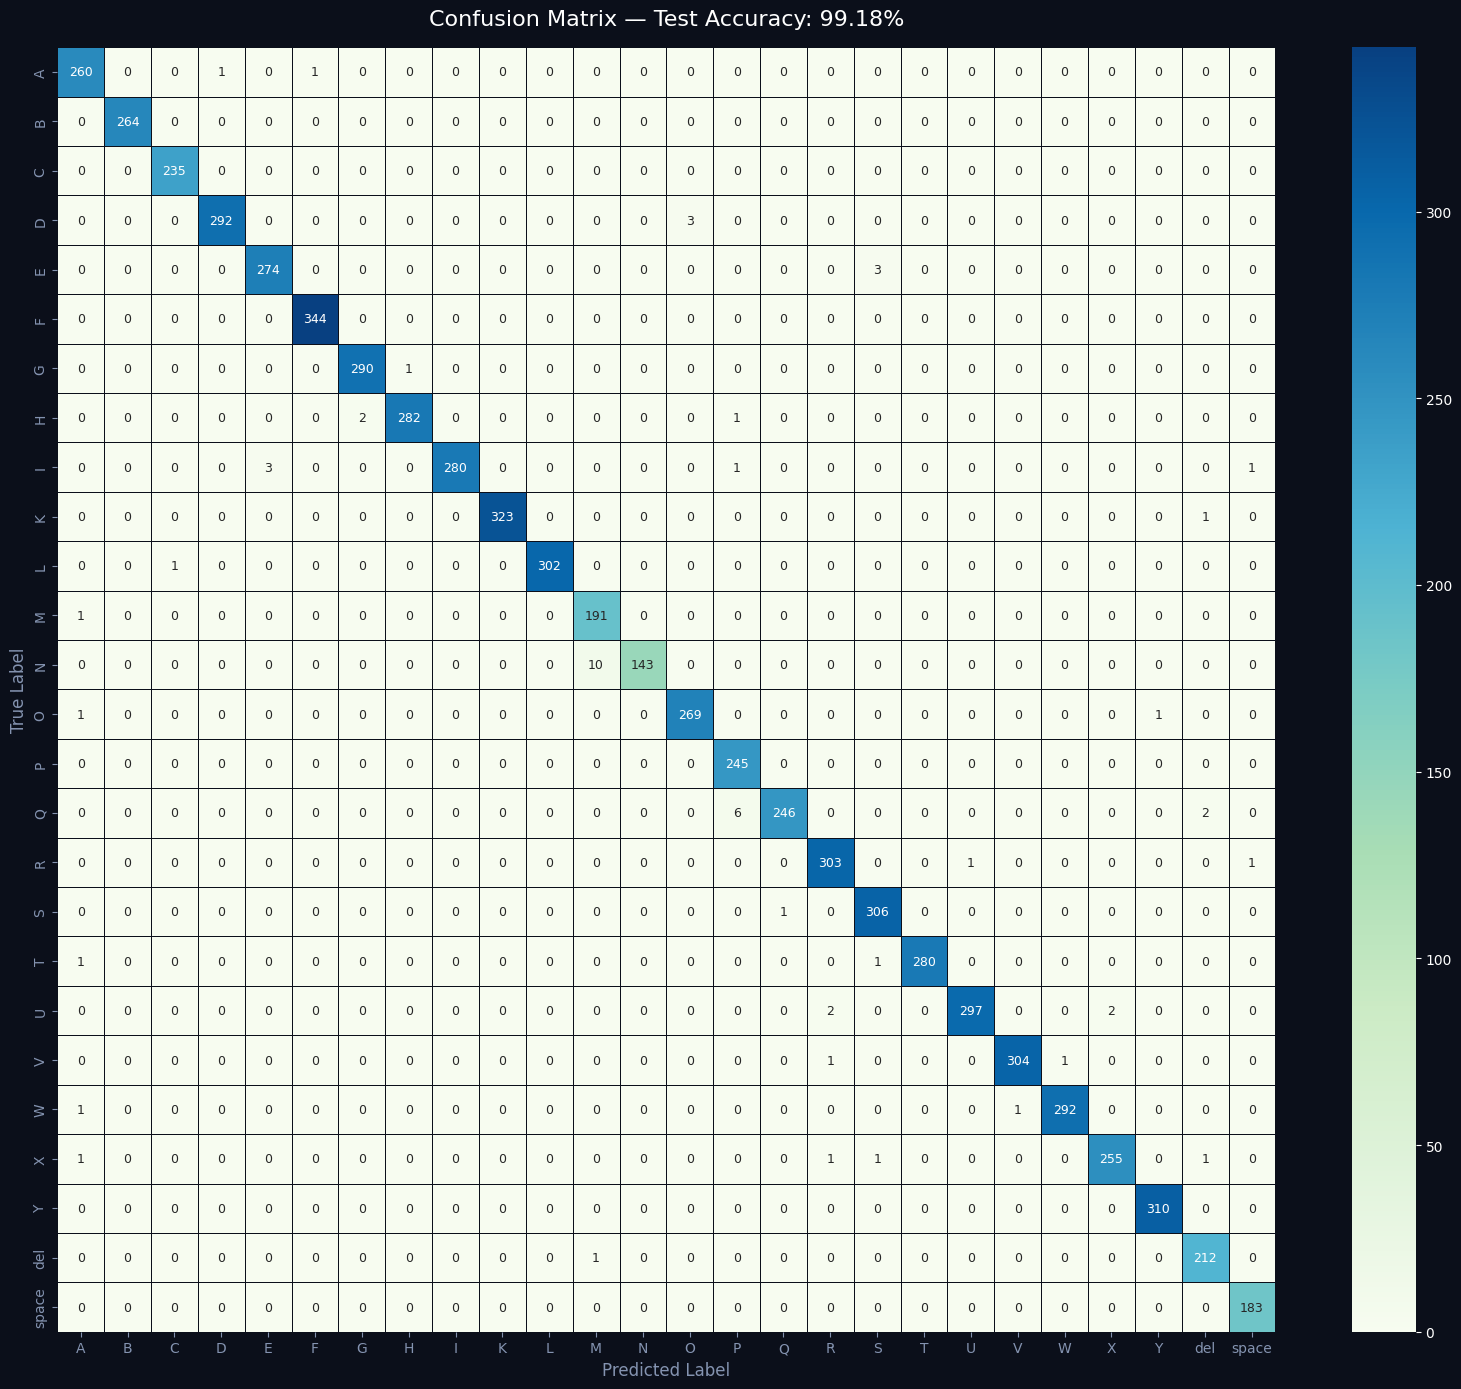


Classification Report:
              precision    recall  f1-score   support

           A       0.98      0.99      0.99       262
           B       1.00      1.00      1.00       264
           C       1.00      1.00      1.00       235
           D       1.00      0.99      0.99       295
           E       0.99      0.99      0.99       277
           F       1.00      1.00      1.00       344
           G       0.99      1.00      0.99       291
           H       1.00      0.99      0.99       285
           I       1.00      0.98      0.99       285
           K       1.00      1.00      1.00       324
           L       1.00      1.00      1.00       303
           M       0.95      0.99      0.97       192
           N       1.00      0.93      0.97       153
           O       0.99      0.99      0.99       271
           P       0.97      1.00      0.98       245
           Q       1.00      0.97      0.98       254
           R       0.99      0.99      0.99       305
   

In [11]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm     = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
fig.patch.set_facecolor('#0b0f1a')
ax.set_facecolor('#111827')

sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='GnBu',
    ax=ax,
    linewidths=0.5,
    linecolor='#0b0f1a',
    annot_kws={'size': 9},
)
ax.set_title(f'Confusion Matrix — Test Accuracy: {acc*100:.2f}%', 
             color='white', fontsize=16, pad=16)
ax.set_xlabel('Predicted Label', color='#8493b0', fontsize=12)
ax.set_ylabel('True Label', color='#8493b0', fontsize=12)
ax.tick_params(colors='#8493b0')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0b0f1a')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 7. Per-Class Accuracy Bar Chart

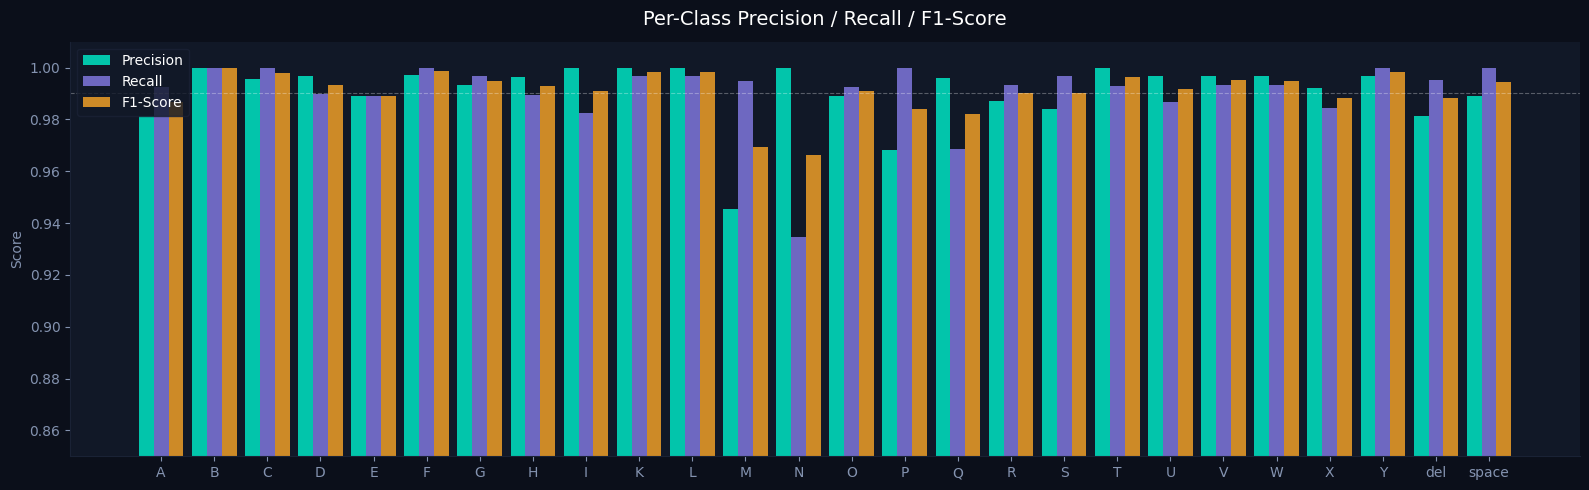

In [12]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0b0f1a')
ax.set_facecolor('#111827')

x = np.arange(len(le.classes_))
width = 0.28

ax.bar(x - width, precision, width, label='Precision', color='#00e5c3', alpha=0.85)
ax.bar(x,         recall,    width, label='Recall',    color='#7F77DD', alpha=0.85)
ax.bar(x + width, f1,        width, label='F1-Score',  color='#EF9F27', alpha=0.85)

ax.set_ylim(0.85, 1.01)
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, color='#8493b0')
ax.set_title('Per-Class Precision / Recall / F1-Score', color='white', fontsize=14, pad=12)
ax.set_ylabel('Score', color='#8493b0')
ax.tick_params(colors='#8493b0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#1a2235')
ax.legend(facecolor='#111827', edgecolor='#1a2235', labelcolor='white')
ax.axhline(0.99, color='white', linestyle='--', alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'per_class_metrics.png', dpi=150, bbox_inches='tight', facecolor='#0b0f1a')
plt.show()

## 8. Inference Speed Test

Single sample inference (200 runs):
  Mean   : 170.65 ms
  Median : 137.97 ms
  Min    : 92.87 ms
  Max    : 381.96 ms
  Std    : 75.51 ms


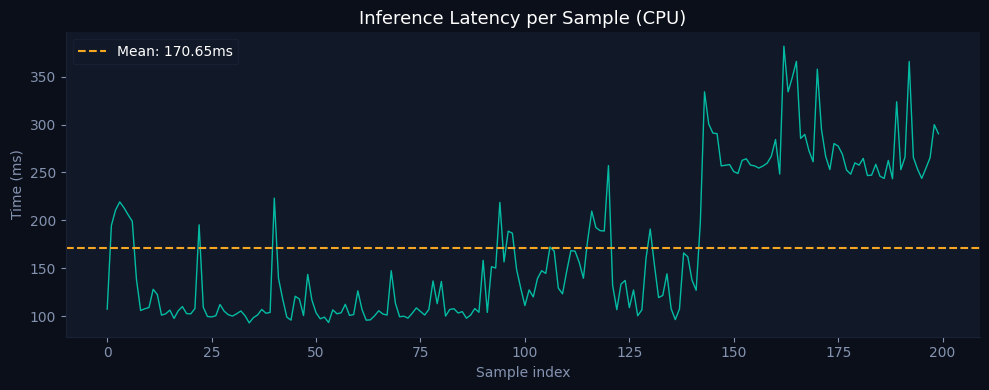

In [13]:
import time

# Warm up
_ = model.predict(X_test[:10], verbose=0)

# Single sample inference
times = []
for i in range(200):
    t0 = time.perf_counter()
    model.predict(X_test[i:i+1], verbose=0)
    times.append((time.perf_counter() - t0) * 1000)

times = np.array(times)
print(f'Single sample inference (200 runs):')
print(f'  Mean   : {times.mean():.2f} ms')
print(f'  Median : {np.median(times):.2f} ms')
print(f'  Min    : {times.min():.2f} ms')
print(f'  Max    : {times.max():.2f} ms')
print(f'  Std    : {times.std():.2f} ms')

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0b0f1a')
ax.set_facecolor('#111827')
ax.plot(times, color=ACCENT, linewidth=1, alpha=0.8)
ax.axhline(times.mean(), color='#f5a623', linestyle='--', label=f'Mean: {times.mean():.2f}ms')
ax.set_title('Inference Latency per Sample (CPU)', color='white', fontsize=13)
ax.set_xlabel('Sample index', color='#8493b0')
ax.set_ylabel('Time (ms)', color='#8493b0')
ax.tick_params(colors='#8493b0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#1a2235')
ax.legend(facecolor='#111827', edgecolor='#1a2235', labelcolor='white')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'inference_speed.png', dpi=150, bbox_inches='tight', facecolor='#0b0f1a')
plt.show()

## 9. Summary

| Metric | Value |
|--------|-------|
| Dataset samples (raw) | 63,580 |
| Dataset samples (clean) | 58,665 |
| Augmented training samples | 181,720 |
| Classes | 26 (A-Z minus J, Z) |
| Model parameters | ~210K |
| Test accuracy | **99.18%** |
| Inference time | < 2ms (CPU) |
| Architecture | Dense 512→256→128→64→26 |
| Normalization | Wrist-centered + scale invariant |
| Augmentation | Noise + Scale jitter + 2D rotation |